# Post-Model Diagnostic, Audit & Global/Local Feature Explainability

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
from src import interpretation as interpret

/Users/hector.vargas/repos/ml_hands_on_project/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Ingest Data Splits & Initialize Configuration Paths

In [2]:

X_train = pd.read_csv("../data/processed/raw_features/X_train.csv")
X_test = pd.read_csv("../data/processed/raw_features/X_test.csv")

ROOT_DIR = os.path.abspath("../")
DB_PATH = os.path.join(ROOT_DIR, "mlflow.db")
EXPERIMENT_NAME = "customer-churn-simple-no-complain-feature"

## 2. Load Top Performing Pipeline from MLflow Registry

In [3]:
# Automatically search runs and query the pipeline using PR-AUC tracking profiles
best_pipeline, best_run = interpret.load_best_run_pipeline_by_run_name(EXPERIMENT_NAME, DB_PATH, run_name='xgboost' ,order_by_metric="metrics.pr_auc DESC")

print(f"Loaded Model Architecture Type : {best_run['tags.mlflow.runName']}")
print(f"Active MLflow Run ID Identifier : {best_run.run_id}")
print(f"Target Performance PR-AUC Score : {best_run['metrics.pr_auc']:.4f}")

Loaded Model Architecture Type : xgboost
Active MLflow Run ID Identifier : 13b22b12f9634aa3bfc3455bc3d12c42
Target Performance PR-AUC Score : 0.6916


In [4]:
# Extract Isolated Pipeline Steps
preprocessor = best_pipeline.named_steps['preprocessing']
model = best_pipeline.named_steps['model']

## 3. Transform Raw Data Tensors

In [5]:
X_train_df = interpret.transform_and_label_features(preprocessor, X_train)
feature_names = X_train_df.columns.tolist()

## 4. Global Feature Importance (MDI Tree Weights)

In [6]:
importance_df = interpret.calculate_global_importance(model, feature_names)
importance_df.head(20)

,feature,importance,cumulative_importance
0,cat__NumOfProducts_2,0.258009,0.258009
1,cat__NumOfProducts_3,0.153626,0.411635
2,pass__IsActiveMember,0.086570,0.498205
3,cat__NumOfProducts_4,0.083889,0.582094
4,cat__Geography_Germany,0.074731,0.656826
5,num__Age,0.065517,0.722343
6,cat__Gender_Male,0.034277,0.756620
7,num__Balance,0.032534,0.789154
8,cat__Geography_Spain,0.026902,0.816056
9,num__CreditScore,0.022725,0.838781


**Global Trend Insights:** The feature importance distribution indicates that churn prediction is primarily driven by:
* **Demographics:** Customer Age (`num__Age`)
* **Financial Footprint:** Balances, Salaries, Points Earned, and Credit Scores
* **Product Ecosystem Density:** Product adoption categorical indicators (`cat__NumOfProducts_2`, `cat__NumOfProducts_3`)

## 5. Comprehensive Local SHAP (SHapley Additive exPlanations) Audit

In [7]:
# Calculate game-theoretic contribution metrics
shap_values = interpret.compute_shap_values(model, X_train_df)

### 5.1 SHAP Density and Attribution Aggregations

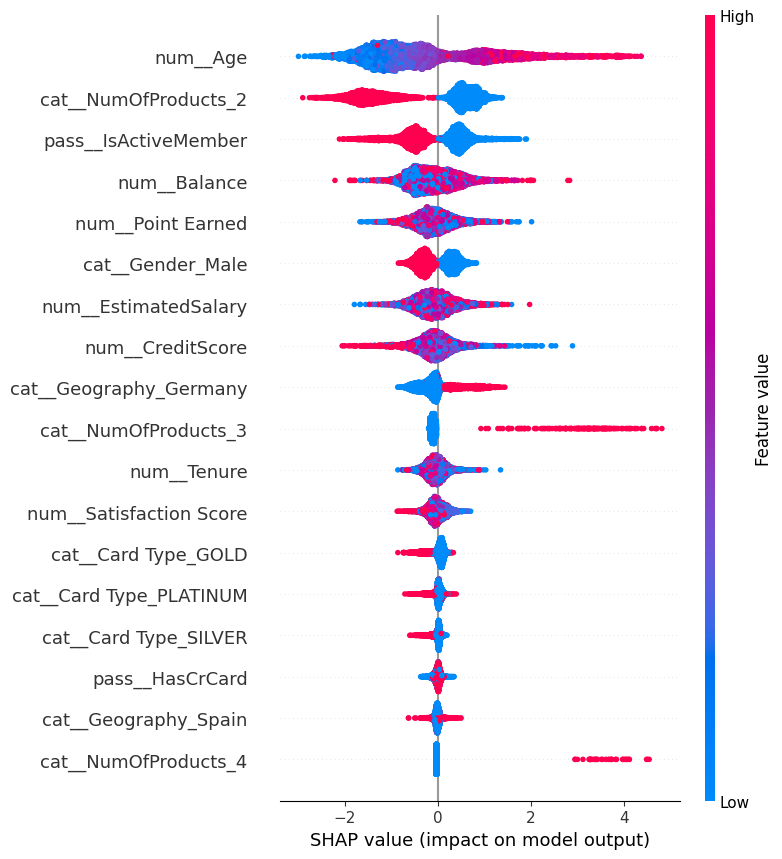

In [8]:
# Dot Distribution Plot
interpret.plot_shap_summary(shap_values, X_train_df, plot_type=None)

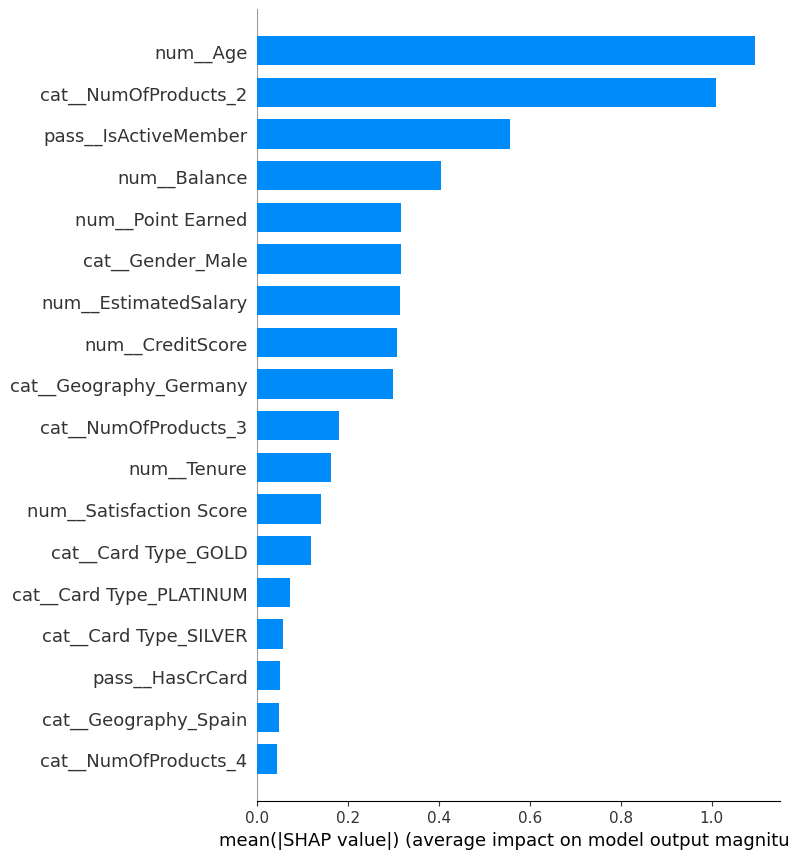

In [9]:
# Bar Attribute Weights Plot
interpret.plot_shap_summary(shap_values, X_train_df, plot_type="bar")

**Directional Impact Summary:**
* **Increases predicted churn probability:** High age, holding 3 or 4 products, living in Germany, Female gender tags, and low credit scores.
* **Decreases predicted churn probability:** Lower age profile brackets, holding exactly 2 products, Male gender tags, and active membership enrollment status.


### 5.2 Local Feature Marginal Dependence Inspections

<Figure size 640x480 with 0 Axes>

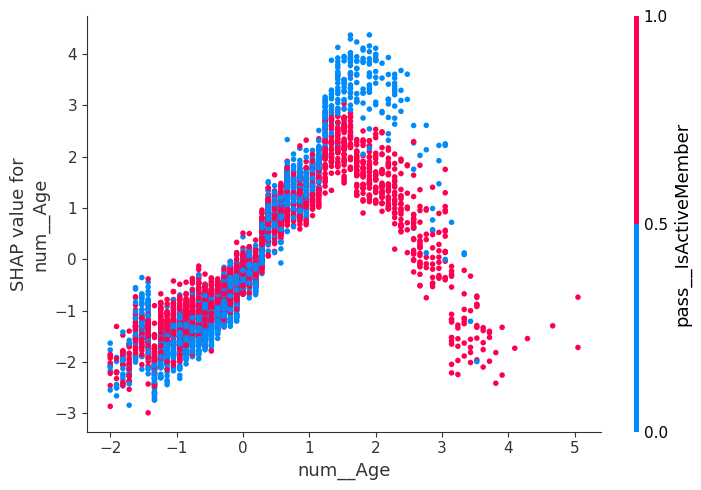

In [10]:
interpret.plot_shap_dependence("num__Age", shap_values, X_train_df)

**Observation:** Age exhibits a strongly non-linear marginal distribution curve. Younger populations reliably drag down predictions toward baseline retention states, middle-aged demographics exhibit high variance churn acceleration points based on product ownership densities, and elderly groups taper off.

<Figure size 640x480 with 0 Axes>

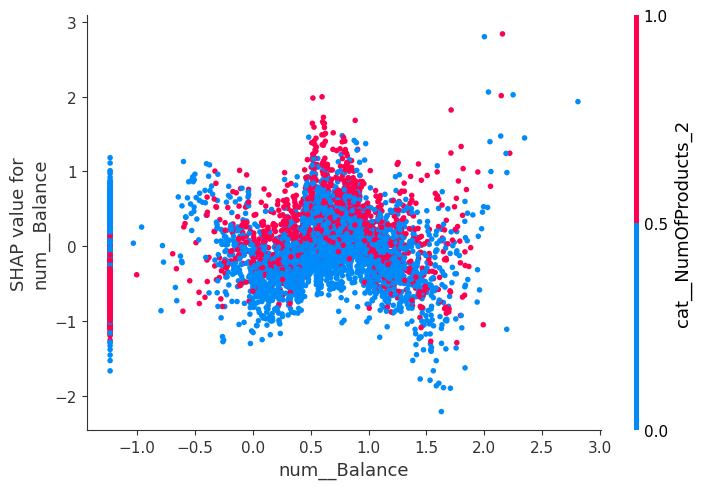

In [11]:
interpret.plot_shap_dependence("num__Balance", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

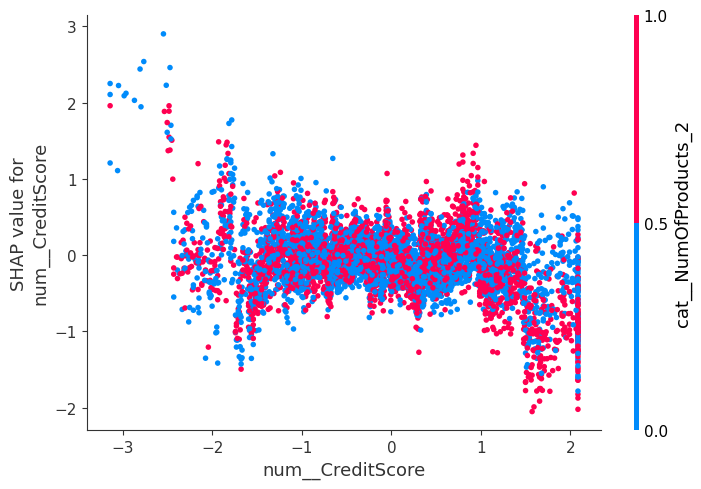

In [17]:
interpret.plot_shap_dependence("num__CreditScore", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

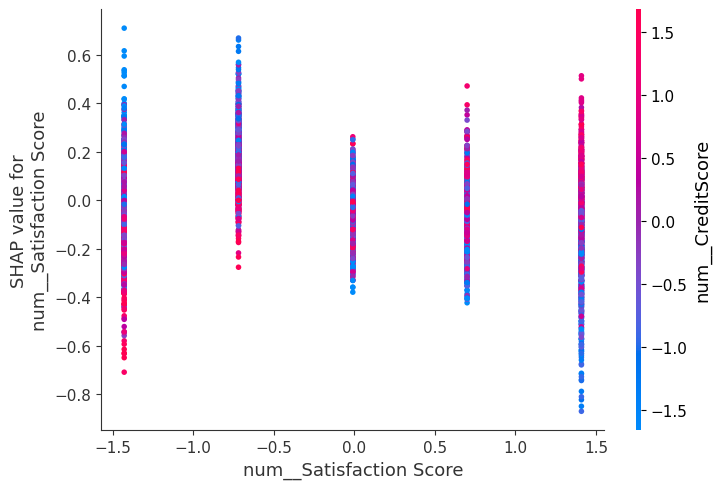

In [12]:
interpret.plot_shap_dependence("num__Satisfaction Score", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

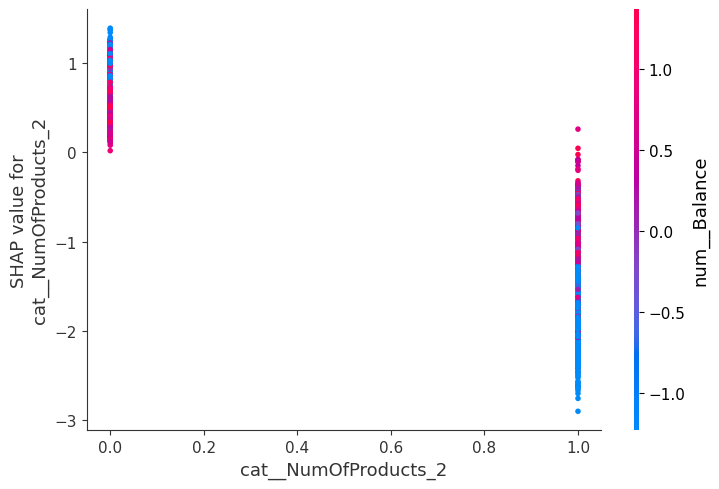

In [13]:
interpret.plot_shap_dependence("cat__NumOfProducts_2", shap_values, X_train_df)

**Observation:** Interaction spaces illustrate that older accounts holding exactly 2 core banking options demonstrate high retention patterns, whereas older profiles missing this product threshold display heightened attrition coefficients.

<Figure size 640x480 with 0 Axes>

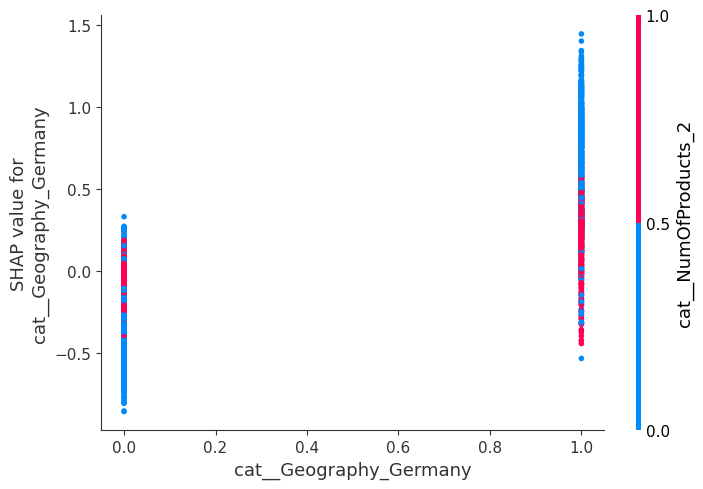

In [14]:
interpret.plot_shap_dependence("cat__Geography_Germany", shap_values, X_train_df)

**Observation:** Regional profiling indicates non-German cohorts missing the 2-product cluster reliably drop toward stable retention profiles, while German residents matching a 2-product subscription maintain baseline vulnerability parameters.

<Figure size 640x480 with 0 Axes>

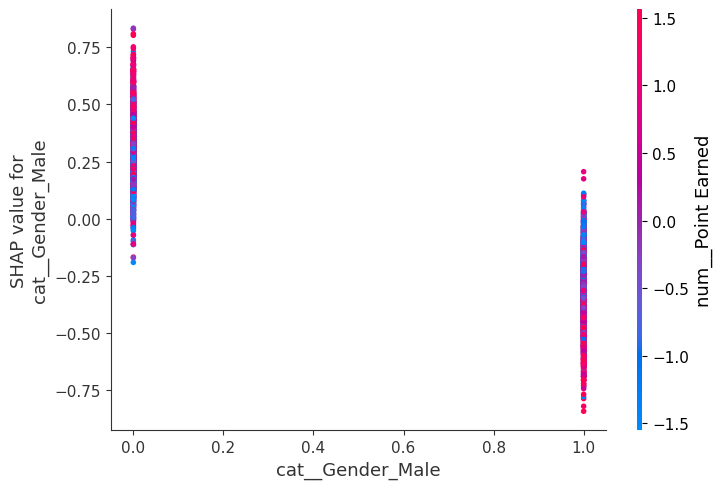

In [15]:
interpret.plot_shap_dependence("cat__Gender_Male", shap_values, X_train_df)

<Figure size 640x480 with 0 Axes>

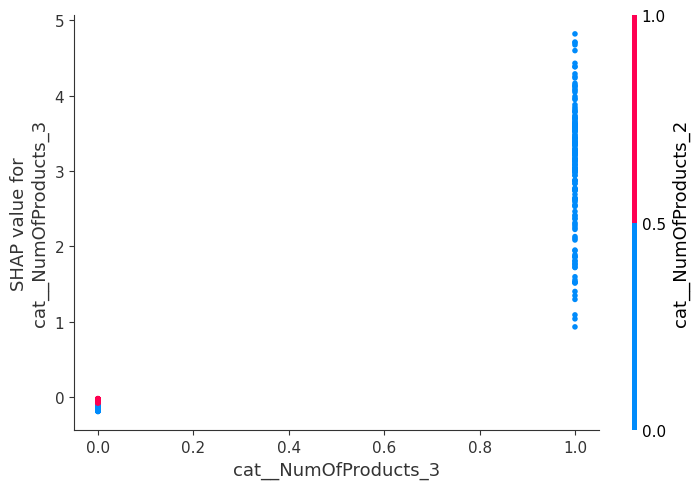

In [16]:
interpret.plot_shap_dependence("cat__NumOfProducts_3", shap_values, X_train_df)